In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import BallTree
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv('../data/MGKDB_unified_parameters_20260426_154819.csv')  # <-- replace with your file

In [5]:
# ── 2. SELECT PARAMETERS ──────────────────────────────────────────────────────
param_cols = [c for c in df.select_dtypes(include='number').columns]
print(f"Automatically selected {len(param_cols)} numeric parameters: \n{param_cols}")
# Or specify manually:
# param_cols = ['ky', 'q', 'Ti_over_Te', 'dens_grad_ion', ...]

df_params = df[param_cols].dropna()
print(f"Using {len(df_params)} records across {len(param_cols)} parameters")

# ── 3. NORMALIZE TO [0, 1] ────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_params)

# ── 4. SAMPLE CANDIDATE GRID POINTS ──────────────────────────────────────────
# Increase n_candidates for finer resolution
n_candidates = 50_000
n_dims = X_scaled.shape[1]
np.random.seed(42)
candidates = np.random.uniform(0, 1, size=(n_candidates, n_dims))


Automatically selected 13 numeric parameters: 
['Beta', 'q', 'collisionality_elec', 's-hat', 'temp_grad_elec', 'temp_grad_ion', 'dens_grad_elec', 'dens_grad_ion', 'impurity_density', 'impurity_charge', 'alpha_MHD', 'Ti_over_Te', 'ky']
Using 24563 records across 13 parameters


In [6]:
# ── 5. NEAREST-NEIGHBOR DISTANCE (approximate Voronoi circumradius) ───────────
print("Building BallTree and querying nearest neighbors...")
tree = BallTree(X_scaled)
distances, _ = tree.query(candidates, k=1)
distances = distances.flatten()

# ── 6. RANK VOIDS ─────────────────────────────────────────────────────────────
top_n = 20
top_idx = np.argsort(distances)[::-1][:top_n]
top_centers_scaled = candidates[top_idx]
top_radii_scaled   = distances[top_idx]
top_centers_real   = scaler.inverse_transform(top_centers_scaled)

void_df = pd.DataFrame(top_centers_real, columns=param_cols)
void_df.insert(0, 'void_radius_scaled', top_radii_scaled)
void_df.index = void_df.index + 1
void_df.index.name = 'rank'
print(void_df)

Building BallTree and querying nearest neighbors...
      void_radius_scaled      Beta          q  collisionality_elec      s-hat  \
rank                                                                            
1               2.108895  0.324986   4.111098            27.694866  21.599605   
2               2.082196  0.311951  11.100218             8.182661  41.654705   
3               2.039130  0.332705  12.960634            26.683397   1.959147   
4               2.033144  0.307126   6.862264            28.931005  12.432632   
5               2.028835  0.330064   2.801572            28.408936  20.081364   
6               2.012155  0.287443  11.036195            28.148520  36.070116   
7               2.003525  0.325975  -5.052473            28.545521  32.158411   
8               1.996515  0.306676  10.315981            28.638828  46.319413   
9               1.994420  0.256356  12.313118            24.225452  -4.490406   
10              1.989317  0.325725  10.385900            

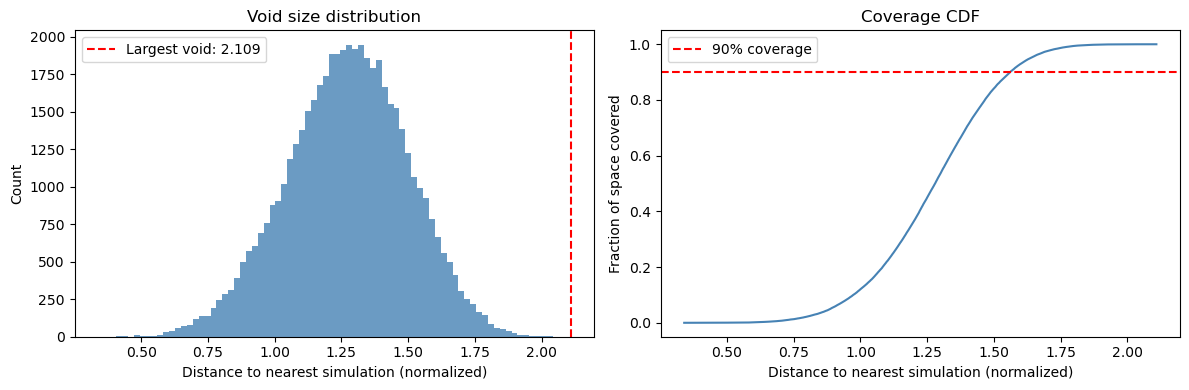

In [7]:
# ── 7. PLOT: VOID RADIUS DISTRIBUTION + COVERAGE CDF ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(distances, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(top_radii_scaled[0], color='red', linestyle='--',
                label=f'Largest void: {top_radii_scaled[0]:.3f}')
axes[0].set_xlabel('Distance to nearest simulation (normalized)')
axes[0].set_ylabel('Count')
axes[0].set_title('Void size distribution')
axes[0].legend()

sorted_d = np.sort(distances)
cdf = np.arange(1, len(sorted_d)+1) / len(sorted_d)
axes[1].plot(sorted_d, cdf, color='steelblue')
axes[1].axhline(0.9, color='red', linestyle='--', label='90% coverage')
axes[1].set_xlabel('Distance to nearest simulation (normalized)')
axes[1].set_ylabel('Fraction of space covered')
axes[1].set_title('Coverage CDF')
axes[1].legend()

plt.tight_layout()
plt.show()


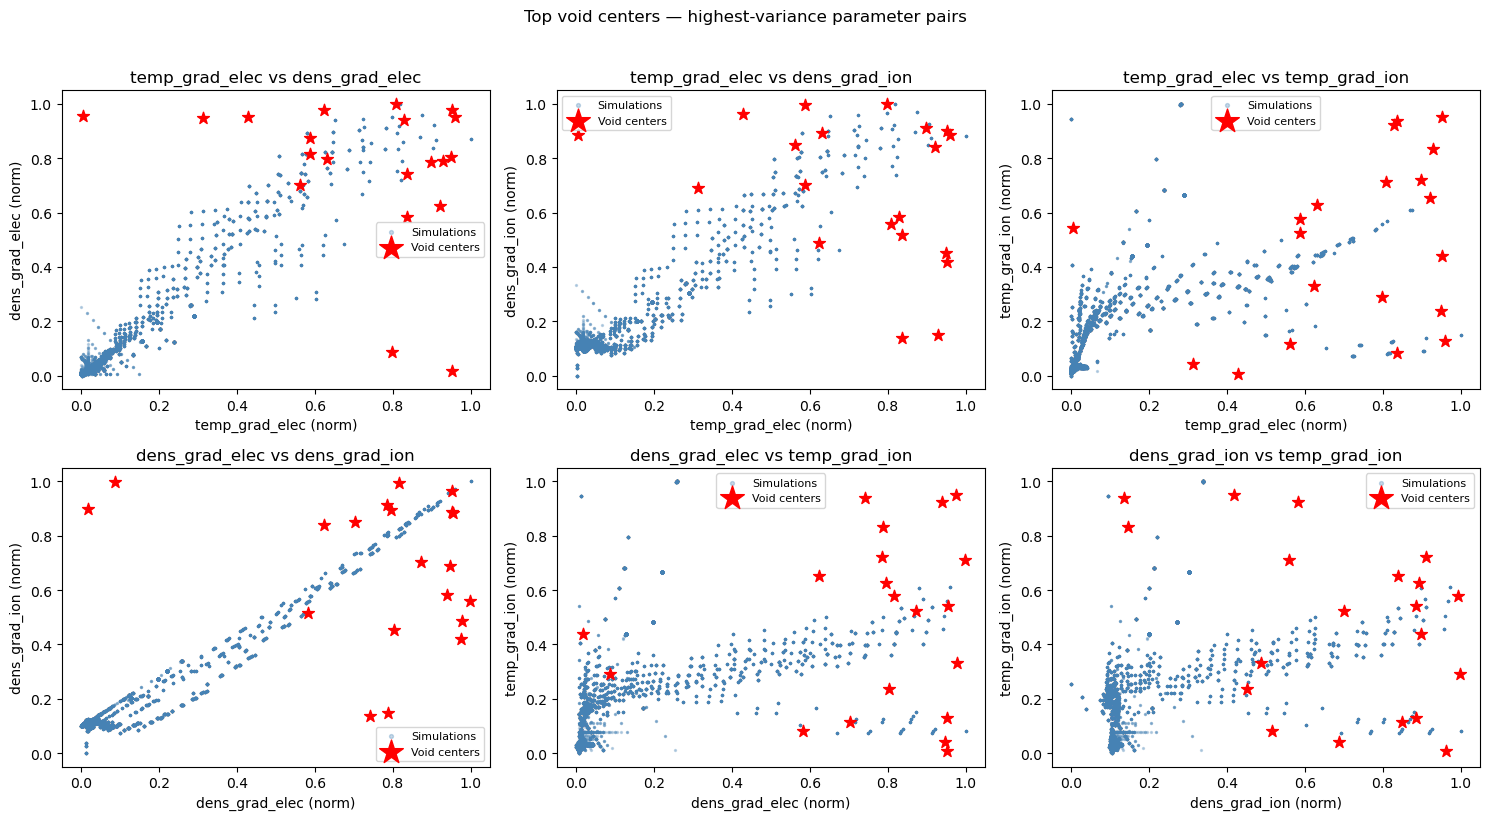

In [10]:

# ── 8. PLOT: 2D PROJECTIONS OF TOP VOIDS ─────────────────────────────────────
# Projects onto the 4 highest-variance parameter pairs
variances = df_params.var().sort_values(ascending=False)
top4 = variances.index[:4].tolist()
top4_idx = [param_cols.index(p) for p in top4]

pairs = list(combinations(range(4), 2))
n_pairs = len(pairs)
n_cols = 3
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, (i, j) in zip(axes, pairs):
    pi, pj = top4_idx[i], top4_idx[j]
    ax.scatter(X_scaled[:, pi], X_scaled[:, pj],
               s=2, alpha=0.3, color='steelblue', label='Simulations')
    ax.scatter(top_centers_scaled[:, pi], top_centers_scaled[:, pj],
               s=80, color='red', marker='*', zorder=5, label='Void centers')
    for cx, cy, r in zip(top_centers_scaled[:, pi], top_centers_scaled[:, pj], top_radii_scaled):
        circle = plt.Circle((cx, cy), r, color='red', fill=False, alpha=0.3, linewidth=0.8)
        ax.add_patch(circle)
    ax.set_xlabel(top4[i] + ' (norm)')
    ax.set_ylabel(top4[j] + ' (norm)')
    ax.set_title(f'{top4[i]} vs {top4[j]}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(markerscale=2, fontsize=8)

# Hide unused subplots
for j in range(len(pairs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top void centers — highest-variance parameter pairs', y=1.02)
plt.tight_layout()
plt.show()

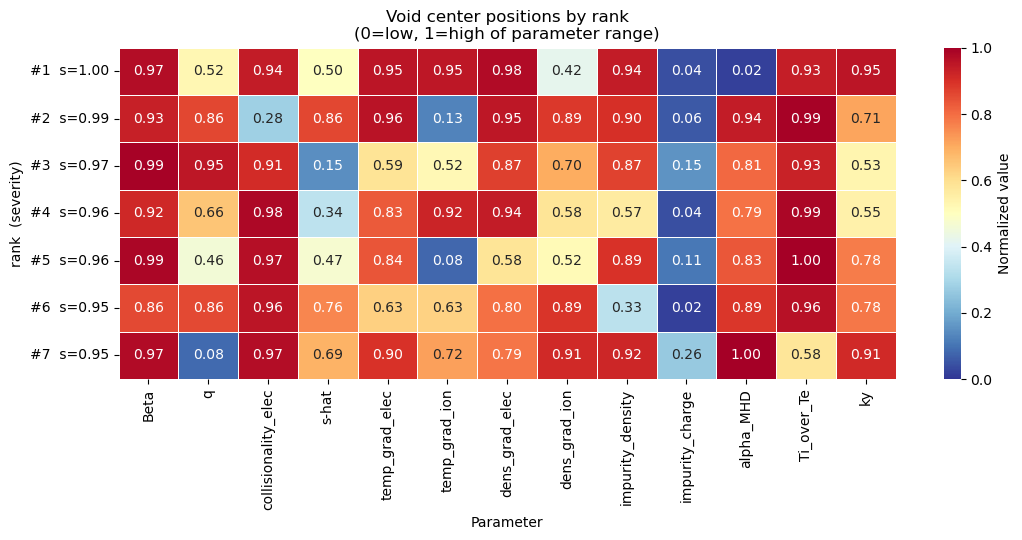

In [15]:
# ── HEATMAP: Top 7 void centers ───────────────────────────────────────────────
void_scaled_df = pd.DataFrame(top_centers_scaled[:top_n], columns=param_cols)

# Severity score as index
severity_scores = top_radii_scaled[:top_n] / top_radii_scaled[0]
void_scaled_df.index = [f'#{r+1}  s={s:.2f}' for r, s in enumerate(severity_scores)]
void_scaled_df.index.name = 'rank  (severity)'

fig1, ax1 = plt.subplots(figsize=(len(param_cols) * 0.7 + 2, top_n * 0.5 + 2))
sns.heatmap(void_scaled_df, ax=ax1, cmap='RdYlBu_r', vmin=0, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Normalized value'})
ax1.set_title('Void center positions by rank\n(0=low, 1=high of parameter range)')
ax1.set_xlabel('Parameter')
plt.tight_layout()
plt.show()

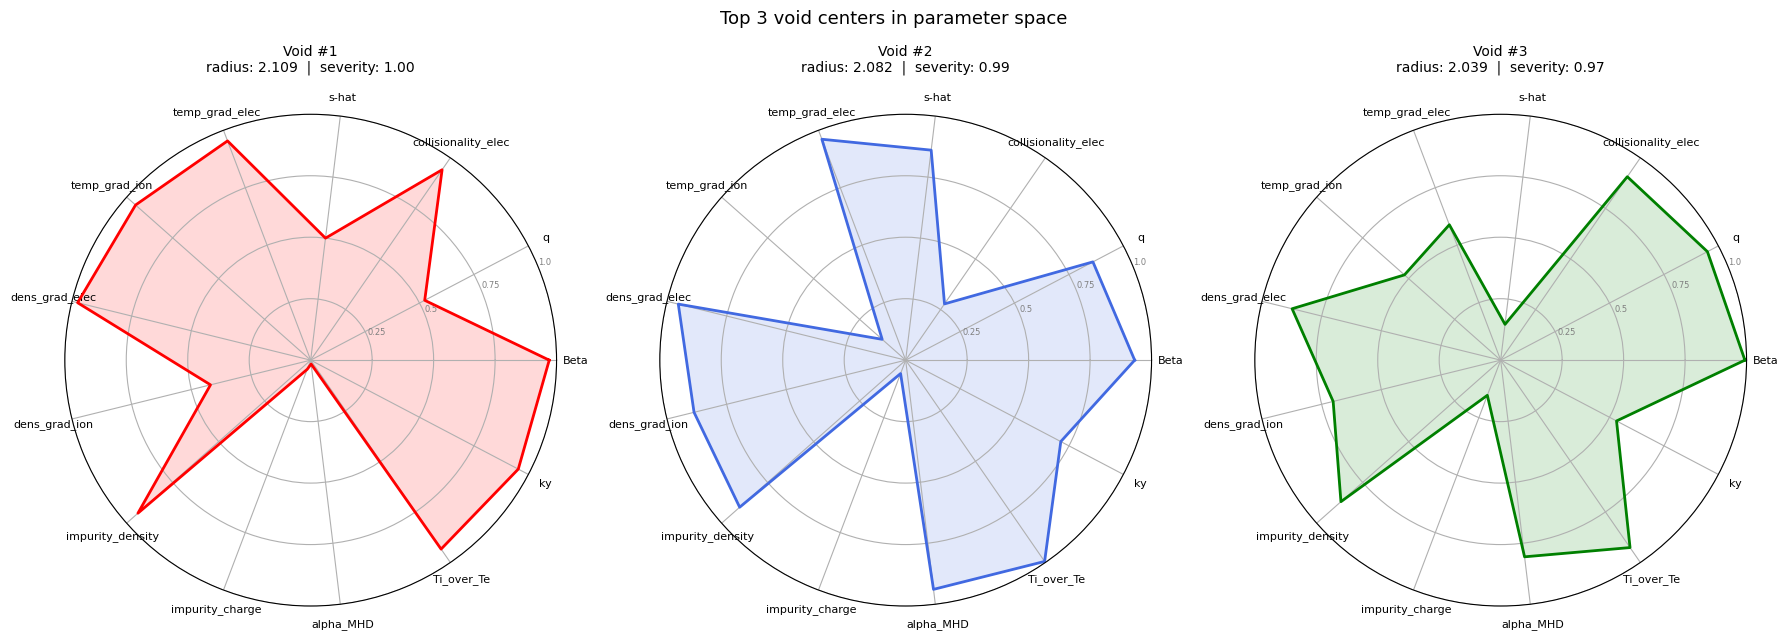

In [16]:
# ── SPIDER PLOT: Top 3 voids ──────────────────────────────────────────────────
n_params = len(param_cols)
angles = np.linspace(0, 2 * np.pi, n_params, endpoint=False).tolist()
angles += angles[:1]  # close the loop

colors = ['red', 'royalblue', 'green']
top_3 = 3

fig2, axes2 = plt.subplots(1, top_3, figsize=(6 * top_3, 6),
                            subplot_kw=dict(polar=True))

for rank in range(top_3):
    ax = axes2[rank]
    values = top_centers_scaled[rank].tolist()
    values += values[:1]

    # Gap severity score: void radius normalized to [0,1] relative to max void
    severity = top_radii_scaled[rank] / top_radii_scaled[0]  # 1.0 for rank 1

    ax.plot(angles, values, color=colors[rank], linewidth=2)
    ax.fill(angles, values, color=colors[rank], alpha=0.15)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(param_cols, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=6, color='grey')
    ax.set_title(
        f'Void #{rank + 1}\n'
        f'radius: {top_radii_scaled[rank]:.3f}  |  severity: {severity:.2f}',
        pad=15, fontsize=10
    )

plt.suptitle('Top 3 void centers in parameter space', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

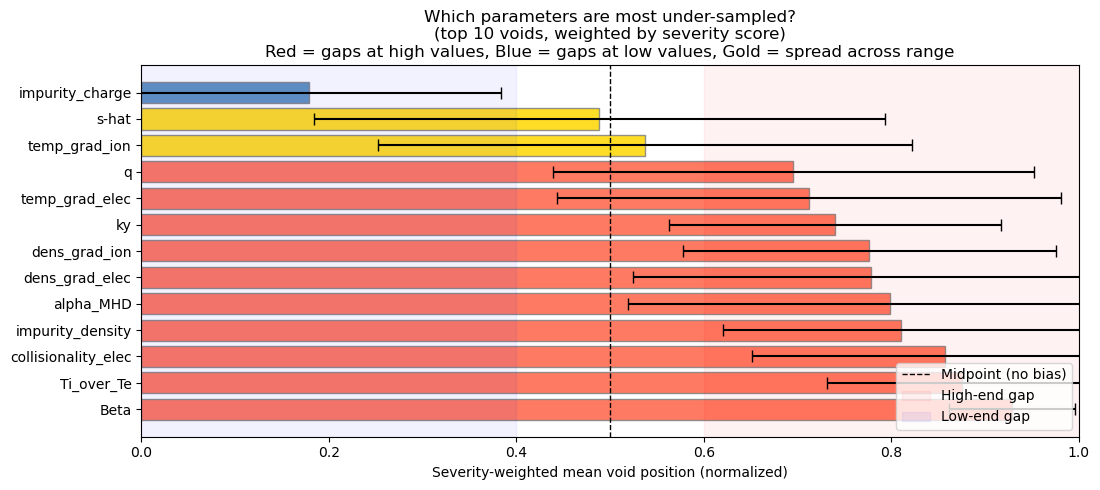


── Parameter gap bias summary ──
          parameter  weighted_mean  weighted_std
               Beta          0.929         0.067
         Ti_over_Te          0.876         0.144
collisionality_elec          0.857         0.206
   impurity_density          0.811         0.190
          alpha_MHD          0.798         0.279
     dens_grad_elec          0.779         0.254
      dens_grad_ion          0.777         0.199
                 ky          0.740         0.177
     temp_grad_elec          0.712         0.269
                  q          0.695         0.256
      temp_grad_ion          0.537         0.285
              s-hat          0.489         0.305
    impurity_charge          0.179         0.205


In [17]:
top_n = 10

# ── PARAMETER COVERAGE BIAS ───────────────────────────────────────────────────
# For each parameter, compute weighted sum of void center positions
# weighted by severity score — high value = consistently under-sampled at high end
# low value = consistently under-sampled at low end
# near 0.5 = gaps spread across the full range

severity_scores = top_radii_scaled[:top_n] / top_radii_scaled[0]
void_scaled_top = top_centers_scaled[:top_n]  # shape (top_n, n_params)

# Weighted mean position of voids per parameter
weighted_mean = np.average(void_scaled_top, axis=0, weights=severity_scores)

# Weighted std — how spread are the voids for this parameter?
weighted_var = np.average((void_scaled_top - weighted_mean)**2, axis=0, weights=severity_scores)
weighted_std = np.sqrt(weighted_var)

bias_df = pd.DataFrame({
    'parameter': param_cols,
    'weighted_mean': weighted_mean,
    'weighted_std': weighted_std,
}).sort_values('weighted_mean', ascending=False)

fig, ax = plt.subplots(figsize=(len(param_cols) * 0.7 + 2, 5))

bars = ax.barh(bias_df['parameter'], bias_df['weighted_mean'],
               xerr=bias_df['weighted_std'],
               color=['tomato' if v > 0.6 else 'steelblue' if v < 0.4 else 'gold'
                      for v in bias_df['weighted_mean']],
               edgecolor='grey', alpha=0.85, capsize=4)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Midpoint (no bias)')
ax.axvspan(0.6, 1.0, alpha=0.05, color='red', label='High-end gap')
ax.axvspan(0.0, 0.4, alpha=0.05, color='blue', label='Low-end gap')

ax.set_xlabel('Severity-weighted mean void position (normalized)')
ax.set_title(f'Which parameters are most under-sampled?\n'
             f'(top {top_n} voids, weighted by severity score)\n'
             f'Red = gaps at high values, Blue = gaps at low values, Gold = spread across range')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n── Parameter gap bias summary ──")
print(bias_df.to_string(index=False, float_format='{:.3f}'.format))